# Polypharmacy Drug-Drug Interaction (DDI) Prediction System

## Introduction & Objective
The objective of this project is to predict potential side effects that may occur when different drug pairs are used together. To achieve this, machine learning models are used to analyze **Polypharmacy Drug-Drug Interactions (DDI)** using the **TWOSIDES** dataset.

To solve this problem, which is critically important in the bioinformatics and healthcare sectors, we worked with molecular features and SMILES data that represent the chemical structures of drugs. Within the scope of this project:

Because the dataset is massive (~4.6 million rows), a strategic downsampling method was applied while strictly keeping the class balance,

The structure of the data was analyzed using Exploratory Data Analysis (EDA),

High-accuracy predictions were aimed using developed machine learning models (such as XGBoost, Random Forest, etc.).

In the next phase of the project, this developed model will be integrated with a Streamlit interface and turned into a web application.

## System Architecture, Limitations and Warnings

* **Multi-Drug Input and Pairwise Combination Logic:** The developed system supports entering up to 10 drugs in the user interface. However, the model analyzes all entered drugs by splitting them into pairwise combinations. The system runs a separate interaction prediction for each pair and presents a full combination report.

* *Important Limitation:* The model cannot calculate the synergistic effects caused by higher-order combinations (3, 4, or more drugs taken at the same time). For example, all pairwise combinations of 3 drugs entered into the system (A-B, A-C, B-C) may come back as safe, but taking all 3 drugs together could trigger a completely different and unpredictable side effect. Because of how the dataset is structured, the model is not able to predict this kind of combined, multi-drug interaction.


* This project is a purely academic and research-focused machine learning study. The results produced by the model are not definitive medical evidence or a clinically approved diagnosis/prescription, **and should not be treated as real-world medical advice.**

## Data Loading and Libraries

In [ ]:
!pip install PyTDC

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
from tdc.multi_pred import DDI
data = DDI(name = 'TWOSIDES')
df_raw = data.get_data()
print("Original size:", df_raw.shape)
df = df_raw.sample(n=200000, random_state=42).reset_index(drop=True)
print("Sampled size", df.shape)

Downloading...
100%|██████████| 677M/677M [00:48<00:00, 13.9MiB/s]
Loading...
Done!


Original size: (4649441, 5)
Sampled size (200000, 5)


In [4]:
del df_raw
del data
import gc
gc.collect()

120

The TWOSIDES dataset contains 4.6 million drug pair records. Due to RAM limitations, a random subsample ($N=200,000$) was selected while keeping the class balance, and all modeling was performed on this sample.

## Explorary Data Analysis (EDA)

In [5]:
df.head(3)

,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,CID000003121,CCCC(CCC)C(=O)O,CID000003640,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,267
1,CID000002250,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,CID000005002,C1CN(CCN1CCOCCO)C2=NC3=CC=CC=C3SC4=CC=CC=C42,619
2,CID000000853,C1=C(C=C(C(=C1I)OC2=CC(=C(C(=C2)I)O)I)I)CC(C(=...,CID000004168,CCN(CC)CCNC(=O)C1=CC(=C(C=C1OC)N)Cl,1309


In [6]:
all_drugs = pd.concat([df["Drug1_ID"], df["Drug2_ID"]])
total_unique_drugs = all_drugs.nunique()

print(f"Total Number of Interactions: {df.shape[0]}")
print(f"Total Number of Actual Unique Drugs in the System {total_unique_drugs}")

Total Number of Interactions: 200000
Total Number of Actual Unique Drugs in the System 642


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Drug1_ID  200000 non-null  object
 1   Drug1     200000 non-null  object
 2   Drug2_ID  200000 non-null  object
 3   Drug2     200000 non-null  object
 4   Y         200000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 7.6+ MB


,0
Drug1_ID,0
Drug1,0
Drug2_ID,0
Drug2,0
Y,0


There are no missing (null) values in the dataset. The columns Drug1_ID, Drug1, Drug2_ID, and Drug2, which are object types, represent the ID and SMILES code of the drugs. SMILES (Simplified Molecular Input Line Entry System) is a universal standard used to express the structure of chemical molecules as a single line of text that computers can read.

The column Y, which is an integer type, shows the interaction type between Drug1 and Drug2 by numbering them.


In [8]:
df["Y"].value_counts().head(20)

,count
Y,
464,1282
37,1207
258,1104
600,1088
238,1035
692,1030
74,1017
315,1012
648,987


In [9]:
df_most = df["Y"].value_counts().head(20).reset_index()
df_most.columns = ["Y", "count"]

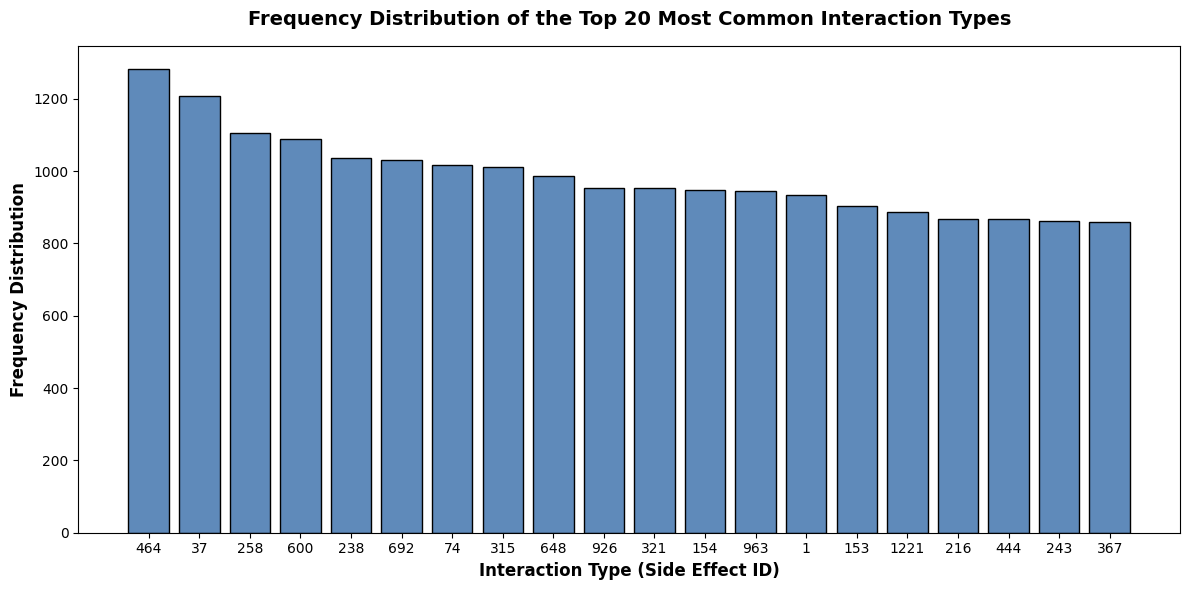

In [10]:
interaction_type = df_most["Y"].astype(str)
count = df_most["count"]

plt.figure(figsize=(12, 6))
plt.bar(interaction_type, count, color="#5f8aba", edgecolor="black")
plt.xlabel("Interaction Type (Side Effect ID)" , fontsize=12, fontweight="bold")
plt.ylabel("Frequency Distribution" , fontsize=12, fontweight="bold")
plt.title("Frequency Distribution of the Top 20 Most Common Interaction Types" , fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [11]:
unique_pairs= df[["Drug1_ID" , "Drug2_ID"]].drop_duplicates()
connections = pd.concat([
    unique_pairs.rename(columns={"Drug1_ID": "DrugID", "Drug2_ID": "Neighbor"}),
    unique_pairs.rename(columns={"Drug2_ID": "DrugID", "Drug1_ID": "Neighbor"})
])
connections

,DrugID,Neighbor
0,CID000003121,CID000003640
1,CID000002250,CID000005002
2,CID000000853,CID000004168
3,CID000003339,CID000003348
4,CID000001302,CID000003121
...,...,...
199927,CID000054808,CID000004583
199939,CID000148192,CID000005514
199950,CID000060843,CID000003350
199958,CID000003467,CID000003043


In [12]:
drug_degrees = connections.groupby("DrugID")["Neighbor"].nunique().reset_index(name="Degree")
drug_degrees.head(5)

,DrugID,Degree
0,CID000000085,36
1,CID000000119,35
2,CID000000143,218
3,CID000000159,69
4,CID000000191,61


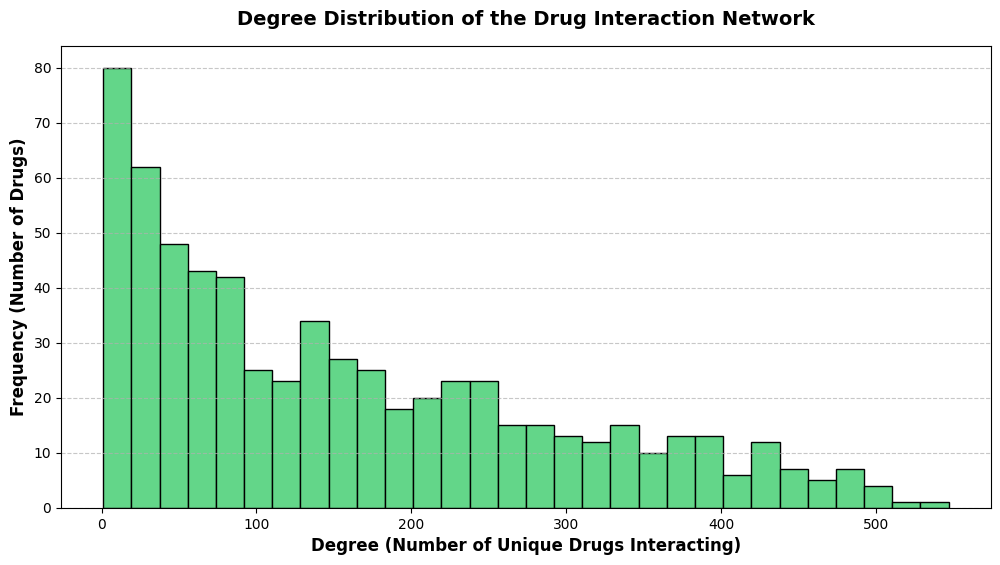

In [13]:
data = drug_degrees["Degree"]
plt.figure(figsize=(12, 6))
plt.hist(data, bins=30, color="#63d689", edgecolor="black")
plt.title("Degree Distribution of the Drug Interaction Network", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Degree (Number of Unique Drugs Interacting)" , fontsize=12, fontweight="bold")
plt.ylabel("Frequency (Number of Drugs)" , fontsize=12, fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
from rdkit import Chem
unique_smiles = set(df["Drug1"].unique()) | set(df["Drug2"].unique())

valid_smiles_set = {
    s for s in unique_smiles
    if isinstance(s, str) and Chem.MolFromSmiles(s) is not None
}

df_clean = df[df["Drug1"].isin(valid_smiles_set) & df["Drug2"].isin(valid_smiles_set)]

print(f"Number of deleted corrupt rows: {len(df) - len(df_clean)}")

Number of deleted corrupt rows: 0


## EDA Findings

* The total number of unique drugs in the reduced dataset is 642, and the total number of interactions is 200,000.

* There are no missing data or undefined drugs. The data quality is extremely high.

* When looking at the frequency distribution of the top 20 most frequent interaction types, we can see that there is no sharp gap between classes, and the frequencies show a smooth transition. This indicates that the model will not experience a serious class imbalance problem for these common classes during training, and the risk of developing a bias while learning these classes will remain at a minimum.

* The degree distribution graph of the drug interaction network shows that the dataset has a scale-free network structure. A small number of probably popular drugs have a very high number of interactions (500+), while the vast majority of drugs have fewer interactions. This creates an imbalance on the input side. The model will learn the chemical structures of highly active (high-degree) drugs much more easily and successfully because there is plenty of data about them. However, since the model has fewer examples for drugs that rarely interact, it may struggle to predict the interactions of these rare drugs.


## Data Preprocessing

In [15]:
df.head(3)

,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,CID000003121,CCCC(CCC)C(=O)O,CID000003640,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,267
1,CID000002250,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,CID000005002,C1CN(CCN1CCOCCO)C2=NC3=CC=CC=C3SC4=CC=CC=C42,619
2,CID000000853,C1=C(C=C(C(=C1I)OC2=CC(=C(C(=C2)I)O)I)I)CC(C(=...,CID000004168,CCN(CC)CCNC(=O)C1=CC(=C(C=C1OC)N)Cl,1309


In [16]:
#rdkit smiles-mol transformation and fingerprinting test (on a single data)
from rdkit.Chem import rdFingerprintGenerator

smiles = df["Drug1"].iloc[0]
print(smiles)

mol = Chem.MolFromSmiles(smiles)
print(mol)

generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = generator.GetFingerprint(mol)
print(fp)
print(type(fp))
fp_array = np.array(fp , dtype=np.uint8)
print(type(fp_array))

CCCC(CCC)C(=O)O
<class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>
<class 'numpy.ndarray'>


When mol object type drug fingerprints are converted, they are transformed into data from a special rdkit library (ExplicitBitVect). Therefore, the resulting fingerprint must be converted back into a numpy array.

In [17]:
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp_dict = dict()

for smiles in unique_smiles:
  mol = Chem.MolFromSmiles(smiles)
  fp = generator.GetFingerprint(mol)
  fp_array = np.array(fp)
  fp_dict[smiles]= fp_array

In [18]:
print(len(fp_dict))
print(len(unique_smiles))

example_smiles = list(fp_dict.keys())[0]
print(fp_dict[example_smiles].shape)
print(fp_dict[example_smiles].dtype)

642
642
(2048,)
int64


All SMILES values ​​have been processed as fingerprints. Fingerprint Size (2048) has not been exceeded. No errors have occurred.

In [19]:
df["Fingerprints1"]=df["Drug1"].map(fp_dict)
df["Fingerprints2"]=df["Drug2"].map(fp_dict)
df.head(5)

,Drug1_ID,Drug1,Drug2_ID,Drug2,Y,Fingerprints1,Fingerprints2
0,CID000003121,CCCC(CCC)C(=O)O,CID000003640,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,267,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CID000002250,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,CID000005002,C1CN(CCN1CCOCCO)C2=NC3=CC=CC=C3SC4=CC=CC=C42,619,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,CID000000853,C1=C(C=C(C(=C1I)OC2=CC(=C(C(=C2)I)O)I)I)CC(C(=...,CID000004168,CCN(CC)CCNC(=O)C1=CC(=C(C=C1OC)N)Cl,1309,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
3,CID000003339,CC(C)OC(=O)C(C)(C)OC1=CC=C(C=C1)C(=O)C2=CC=C(C...,CID000003348,CC(C)(C1=CC=C(C=C1)C(CCCN2CCC(CC2)C(C3=CC=CC=C...,247,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CID000001302,CC(C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,CID000003121,CCCC(CCC)C(=O)O,231,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [20]:
print(df["Fingerprints1"].isna().sum())
print(df["Fingerprints2"].isna().sum())

0
0


There is no empty data in columns 1 and 2 of Fingerprints. The fingerprints have been successfully exported to the df.

In [21]:
import random

existing_pairs = set(zip(df["Drug1"], df["Drug2"])) | set(zip(df["Drug2"], df["Drug1"]))

unique_smiles = set(df["Drug1"].unique()) | set(df["Drug2"].unique())
all_smiles = list(unique_smiles)

n_negative = len(df)

negative_pairs = set()
random.seed(42)

while len(negative_pairs) < n_negative:
    d1, d2 = random.sample(all_smiles, 2)
    if (d1, d2) not in existing_pairs and (d1, d2) not in negative_pairs:
        negative_pairs.add((d1, d2))

neg_df = pd.DataFrame(list(negative_pairs), columns=["Drug1", "Drug2"])
neg_df["label"] = 0

df["label"] = 1

full_df = pd.concat([df[["Drug1", "Drug2", "label"]], neg_df], ignore_index=True)
print(full_df.shape)
print(full_df["label"].value_counts())

(400000, 3)
label
1    200000
0    200000
Name: count, dtype: int64


## Negative Sample Generation
The TWOSIDES dataset only contains drug pairs that actually interact, but for a model to learn the difference between "interaction" and "no interaction," it needs both positive and negative samples. Without negative samples, the model always learns to say "interaction present," because it has never seen an example where there isn't one.

Since the dataset has no negative samples, we generate them ourselves, based on a standard approach used in the literature. If two drugs never appear together in the dataset, there is probably no known interaction between them. This assumption is not 100% true. It's just a practical approach, and it is in fact a limitation.


In [22]:
def combine_concat(fp1, fp2):
    return np.concatenate([fp1, fp2])

def build_X(df_input, combine_func, out_dim):
    n = len(df_input)
    X = np.zeros((n, out_dim), dtype=np.uint8)
    for i, row in enumerate(df_input.itertuples(index=False)):
        fp1 = fp_dict[row.Drug1]
        fp2 = fp_dict[row.Drug2]
        X[i] = combine_func(fp1, fp2)
    return X

X_concat = build_X(full_df, combine_concat, out_dim=4096)
y = full_df["label"].values

print(X_concat.shape, X_concat.dtype)
print(X_concat.nbytes / 1e6, "MB")

(400000, 4096) uint8
1638.4 MB


### Vector Combination
To give the classification model the single vector it expects, the two fingerprints can be combined using different methods (such as concatenation, sum, product, or absolute difference).

In this project, concatenation was chosen, since it's the most commonly used method in DDI prediction in the literature and it keeps information loss to a minimum. It presents the information of both molecules to the model in a single package. Each drug's fingerprint is kept as it is, so no information is lost.


## Modeling

### Logistic Regression

In [23]:
from scipy.sparse import csr_matrix

X_sparse = csr_matrix(X_concat)
print(X_sparse.data.nbytes / 1e6, "MB")

x_train, x_test, y_train, y_test = train_test_split(X_sparse, y, test_size=0.2, random_state=42)
log = LogisticRegression(max_iter=1000)
model1 = log.fit(x_train, y_train)
model1.score(x_test, y_test)

35.436768 MB


0.920275

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, ConfusionMatrixDisplay, roc_curve, roc_auc_score

y_pred = model1.predict(x_test)
rc1_score= recall_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", rc1_score)

y_proba = model1.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     39949
           1       0.91      0.93      0.92     40051

    accuracy                           0.92     80000
   macro avg       0.92      0.92      0.92     80000
weighted avg       0.92      0.92      0.92     80000

Confusion Matrix:
 [[36496  3453]
 [ 2925 37126]]
Recall: 0.926968115652543
ROC-AUC: 0.9768280054560263


### Random Forest Classifier

In [25]:
forest = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)
model2 = forest.fit(x_train, y_train)

model2.score(x_test, y_test)

0.850475

In [26]:
y_pred = model2.predict(x_test)
rc2_score= recall_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", rc2_score)

y_proba = model2.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85     39949
           1       0.87      0.83      0.85     40051

    accuracy                           0.85     80000
   macro avg       0.85      0.85      0.85     80000
weighted avg       0.85      0.85      0.85     80000

Confusion Matrix:
 [[34855  5094]
 [ 6868 33183]]
Recall: 0.828518638735612
ROC-AUC: 0.9234299027132356


### XGBoost

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X_concat, y, test_size=0.2, random_state=42)

xgbm = xgb.XGBClassifier(random_state=42)
model3 = xgbm.fit(x_train, y_train)

model3.score(x_test, y_test)

0.8993125

In [28]:
y_pred = model3.predict(x_test)
rc3_score= recall_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", rc3_score)

y_proba = model3.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.91      0.89      0.90     39949
           1       0.89      0.91      0.90     40051

    accuracy                           0.90     80000
   macro avg       0.90      0.90      0.90     80000
weighted avg       0.90      0.90      0.90     80000

Confusion Matrix:
 [[35372  4577]
 [ 3478 36573]]
Recall: 0.9131607200818956
ROC-AUC: 0.9654204062865479


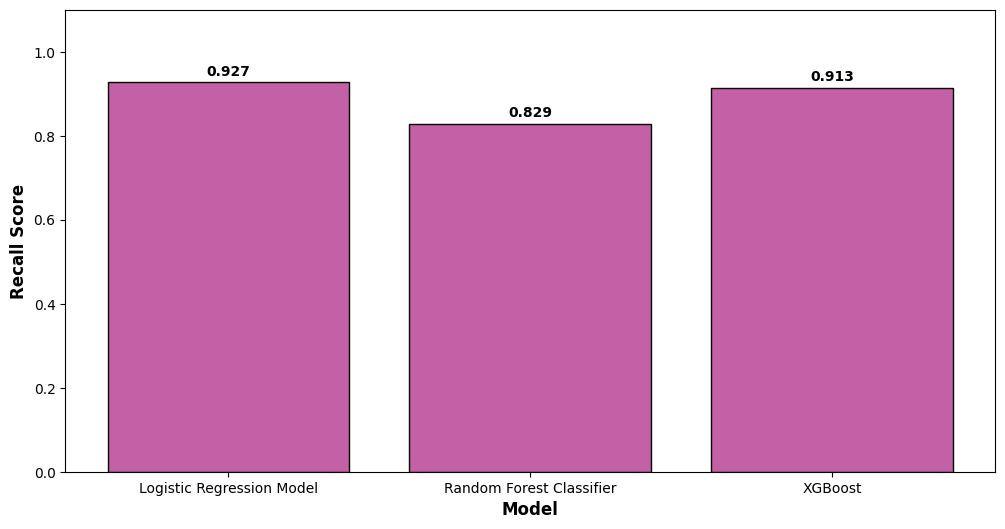

In [29]:
plt.figure(figsize=(12, 6))
categories = ["Logistic Regression Model" , "Random Forest Classifier", "XGBoost"]
scores = [rc1_score, rc2_score, rc3_score]

bars = plt.bar(categories, scores, color="#c460a5", edgecolor="black")

plt.xlabel("Model" , fontsize=12, fontweight="bold")
plt.ylabel("Recall Score" , fontsize=12, fontweight="bold")

plt.bar_label(bars, padding=3, fmt='%.3f', fontweight="bold", fontsize=10)
plt.ylim(0, 1.1)

plt.show()


### Baseline Model Selection
The three models were compared using the same train/test split and fingerprint data combined via concatenation. Since the clinical cost of a missed interaction (False Negative) is high, Recall was the main criterion for model selection, but Precision and ROC-AUC values were also taken into account.

Logistic Regression gave the highest Recall (0.93) and ROC-AUC (0.98) values, followed by XGBoost (Recall: 0.91) and Random Forest (Recall: 0.83).

This result suggests that the high-dimensional, sparse binary structure of the Morgan Fingerprint representation may fit a linear relationship better than the complex, non-linear relationships that tree-based models look for. For this reason, Logistic Regression was chosen as the final model.

### False Positive Rate Analysis

In [31]:
y_test_arr = np.array(y_test)
neg_test_indices = np.where(y_test_arr == 0)[0]

probs = model1.predict_proba(x_test[neg_test_indices])[:, 1]

correct_negative_rate = (probs < 0.5).mean() * 100
false_positive_rate = (probs >= 0.5).mean() * 100

print(f"Out of {len(neg_test_indices)} 'no interaction' samples in the test set:")
print(f"  → Correctly predicted as low risk by the model: {correct_negative_rate:.1f}%")
print(f"  → Incorrectly predicted as high risk (false positive): {false_positive_rate:.1f}%")

Out of 39949 'no interaction' samples in the test set:
  → Correctly predicted as low risk by the model: 91.4%
  → Incorrectly predicted as high risk (false positive): 8.6%


While the model's recall/precision metrics show its overall performance, it is also important to separately examine how often it raises false alarms on drug pairs with no known interaction.

The model correctly classifies 91.5% of negative samples, while producing an 8.5% false positive rate. This is consistent with a recall-first design choice, where the cost of a false negative is considered higher than the cost of a false positive.

## Model Interpretability with SHAP

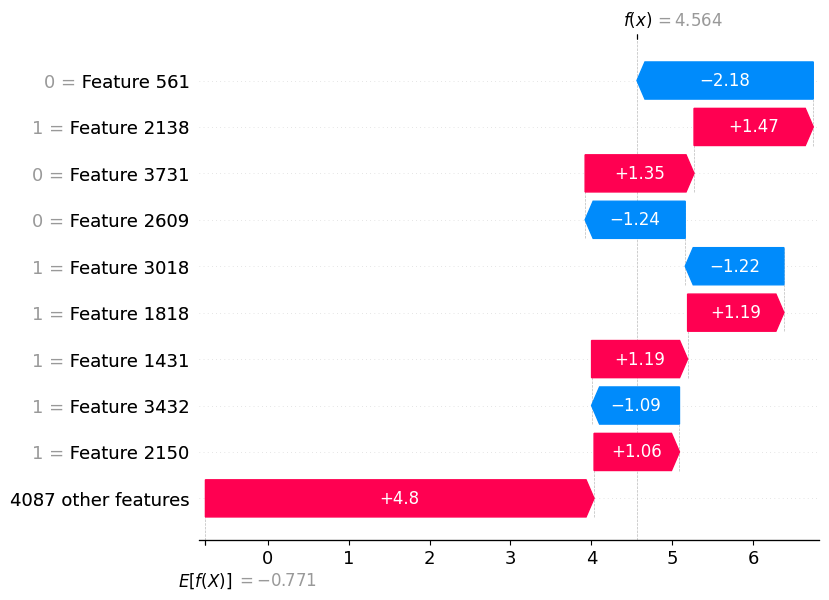

In [30]:
import shap
background = shap.sample(x_train, 100, random_state=42)

explainer = shap.LinearExplainer(model1, background, link=shap.links.logit)

x_test_sample = x_test[:50]
shap_values = explainer(x_test_sample)

shap.plots.waterfall(shap_values[1])


Even though the model produces successful predictions with 93% Recall, we use SHAP (SHapley Additive exPlanations) to explain what input the model based this decision on.

It explains each prediction by showing which features in the input mattered, in which direction, and how much. This matters in a clinical decision-support context — a model shouldn't just say "there's a risk," it should also be able to explain why.

The waterfall plot above shows, step by step, how the model reached its decision for a randomly selected test example. E[f(X)] = -0.998 is the model's average prediction across the whole dataset (the reference point). For this specific example, the model produced a score of f(x) = 4.385. That's clearly above the average, meaning the model strongly supports the idea that this pair interacts. Despite a few features pulling the score down, a large number of small positive contributions added up and dominated, which led the model to classify this pair as high risk.

For this drug pair, the absence of Feature 561 (0 = Feature 561) had the single strongest negative effect (-2.34) — meaning that not having this bit lowers the risk somewhat. Even so, the presence of 8 other bits, and especially the combined effect of the remaining 4087 features (+3.01), outweighed that one negative effect by a wide margin. As a result, the model produced a high risk score of 4.385, well above the average (-0.998) — strongly supporting the likelihood that these two drugs interact.


## Next Steps

This model will be deployed via Streamlit in VS Code.